In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

In [ ]:
import kagglehub
path = kagglehub.dataset_download('ulrikthygepedersen/voters-and-non-voters')

print("Path to dataset files:" , path)

Using Colab cache for faster access to the 'voters-and-non-voters' dataset.
Path to dataset files: /kaggle/input/voters-and-non-voters


In [ ]:
df = pd.read_csv(path + '/nonvoters_dataset.csv')
df

,RespId,educ,race,gender,income_cat,voter_category
0,470001,College,White,Female,$75-125k,always
1,470002,College,White,Female,$125k or more,always
2,470003,College,White,Male,$125k or more,sporadic
3,470007,Some college,Black,Female,$40-75k,sporadic
4,480008,High school or less,White,Male,$40-75k,always
...,...,...,...,...,...,...
5831,477662,Some college,Hispanic,Male,$40-75k,always
5832,477663,High school or less,White,Female,$125k or more,rarely/never
5833,488322,College,Other/Mixed,Male,$125k or more,sporadic
5834,488325,High school or less,Black,Female,Less than $40k,always


In [ ]:
df['educ'].unique()

array(['College', 'Some college', 'High school or less'], dtype=object)

In [ ]:
#Educ Ordinal
from sklearn.preprocessing import OrdinalEncoder
educ_order = ['High school or less' , 'Some college' , 'College']
ordinal = OrdinalEncoder(categories = [educ_order])
df['educ'] = ordinal.fit_transform(df[['educ']])

In [ ]:
df

,RespId,educ,race,gender,income_cat,voter_category
0,470001,2.0,White,Female,$75-125k,always
1,470002,2.0,White,Female,$125k or more,always
2,470003,2.0,White,Male,$125k or more,sporadic
3,470007,1.0,Black,Female,$40-75k,sporadic
4,480008,0.0,White,Male,$40-75k,always
...,...,...,...,...,...,...
5831,477662,1.0,Hispanic,Male,$40-75k,always
5832,477663,0.0,White,Female,$125k or more,rarely/never
5833,488322,2.0,Other/Mixed,Male,$125k or more,sporadic
5834,488325,0.0,Black,Female,Less than $40k,always


In [ ]:
df['race'].unique()

array(['White', 'Black', 'Other/Mixed', 'Hispanic'], dtype=object)

In [ ]:
#Race OneHot
from sklearn.preprocessing import OneHotEncoder
ohe_race = OneHotEncoder(handle_unknown = 'ignore' , sparse_output = False).set_output(transform = 'pandas')
ohe_race = ohe_race.fit_transform(df[['race']])

In [ ]:
df = pd.concat([df , ohe_race] , axis = 1)
df

,RespId,educ,race,gender,income_cat,voter_category,race_Black,race_Hispanic,race_Other/Mixed,race_White
0,470001,2.0,White,Female,$75-125k,always,0.0,0.0,0.0,1.0
1,470002,2.0,White,Female,$125k or more,always,0.0,0.0,0.0,1.0
2,470003,2.0,White,Male,$125k or more,sporadic,0.0,0.0,0.0,1.0
3,470007,1.0,Black,Female,$40-75k,sporadic,1.0,0.0,0.0,0.0
4,480008,0.0,White,Male,$40-75k,always,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
5831,477662,1.0,Hispanic,Male,$40-75k,always,0.0,1.0,0.0,0.0
5832,477663,0.0,White,Female,$125k or more,rarely/never,0.0,0.0,0.0,1.0
5833,488322,2.0,Other/Mixed,Male,$125k or more,sporadic,0.0,0.0,1.0,0.0
5834,488325,0.0,Black,Female,Less than $40k,always,1.0,0.0,0.0,0.0


In [ ]:
#Gender OneHot
ohe_gender = OneHotEncoder(handle_unknown = 'ignore' , sparse_output = False).set_output(transform = 'pandas')
ohe_gender = ohe_gender.fit_transform(df[['gender']])

In [ ]:
df = pd.concat([df , ohe_gender] , axis = 1)
df

,RespId,educ,race,gender,income_cat,voter_category,race_Black,race_Hispanic,race_Other/Mixed,race_White,gender_Female,gender_Male
0,470001,2.0,White,Female,$75-125k,always,0.0,0.0,0.0,1.0,1.0,0.0
1,470002,2.0,White,Female,$125k or more,always,0.0,0.0,0.0,1.0,1.0,0.0
2,470003,2.0,White,Male,$125k or more,sporadic,0.0,0.0,0.0,1.0,0.0,1.0
3,470007,1.0,Black,Female,$40-75k,sporadic,1.0,0.0,0.0,0.0,1.0,0.0
4,480008,0.0,White,Male,$40-75k,always,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
5831,477662,1.0,Hispanic,Male,$40-75k,always,0.0,1.0,0.0,0.0,0.0,1.0
5832,477663,0.0,White,Female,$125k or more,rarely/never,0.0,0.0,0.0,1.0,1.0,0.0
5833,488322,2.0,Other/Mixed,Male,$125k or more,sporadic,0.0,0.0,1.0,0.0,0.0,1.0
5834,488325,0.0,Black,Female,Less than $40k,always,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
#income_cat Ordinal
df['income_cat'].unique()

array(['$75-125k', '$125k or more', '$40-75k', 'Less than $40k'],
      dtype=object)

In [ ]:
income_cat_order = ['Less than $40k' , '$40-75k' , '$75-125k' , '$125k or more']
ordinal = OrdinalEncoder(categories = [income_cat_order])
df['income_cat'] = ordinal.fit_transform(df[['income_cat']])

In [ ]:
df = df.drop(['race' , 'gender'] , axis = 1)
df

,RespId,educ,income_cat,voter_category,race_Black,race_Hispanic,race_Other/Mixed,race_White,gender_Female,gender_Male
0,470001,2.0,2.0,always,0.0,0.0,0.0,1.0,1.0,0.0
1,470002,2.0,3.0,always,0.0,0.0,0.0,1.0,1.0,0.0
2,470003,2.0,3.0,sporadic,0.0,0.0,0.0,1.0,0.0,1.0
3,470007,1.0,1.0,sporadic,1.0,0.0,0.0,0.0,1.0,0.0
4,480008,0.0,1.0,always,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
5831,477662,1.0,1.0,always,0.0,1.0,0.0,0.0,0.0,1.0
5832,477663,0.0,3.0,rarely/never,0.0,0.0,0.0,1.0,1.0,0.0
5833,488322,2.0,3.0,sporadic,0.0,0.0,1.0,0.0,0.0,1.0
5834,488325,0.0,0.0,always,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df = df.dropna()
df.shape

(5836, 10)

In [ ]:
x = df[['educ', 'income_cat', 'race_Black', 'race_Hispanic', 'race_Other/Mixed', 'race_White', 'gender_Female', 'gender_Male']]
y = df['voter_category']
log_reg = linear_model.LogisticRegression()
log_reg.fit(x, y)

LogisticRegression()

In [ ]:
print('Education level: 0 for High school or less, 1 for Some college, 2 for College')
print()
print('Income category: 0 for Less than $40k, 1 for $40-75k, 2 for $75-125k, 3 for $125k or more')
print()
print('Race options: 0 for Black, 1 for Hispanic, 2 for Other/Mixed, 3 for White')
print()
print('Gender options: 0 for Female, 1 for Male')
print()

educ = int(input('Enter education level: '))
income_cat = int(input('Enter income category: '))
race_choice = int(input('Enter race option: '))
gender_choice = int(input('Enter gender option: '))

print()

race_Black = 1 if race_choice == 0 else 0
race_Hispanic = 1 if race_choice == 1 else 0
race_Other_Mixed = 1 if race_choice == 2 else 0
race_White = 1 if race_choice == 3 else 0

gender_Female = 1 if gender_choice == 0 else 0
gender_Male = 1 if gender_choice == 1 else 0

input_data = pd.DataFrame([[educ, income_cat, race_Black, race_Hispanic, race_Other_Mixed, race_White, gender_Female, gender_Male]],
                          columns=['educ', 'income_cat', 'race_Black', 'race_Hispanic', 'race_Other/Mixed', 'race_White', 'gender_Female', 'gender_Male'])

prediction = log_reg.predict(input_data)

if prediction[0] == 'always':
    print('The person is likely to be a voter.')
elif prediction[0] == 'sporadic':
    print('The person is likely to be a sporadic voter.')
else:
    print('The person is likely to rarely/never vote.')

Education level: 0 for High school or less, 1 for Some college, 2 for College

Income category: 0 for Less than $40k, 1 for $40-75k, 2 for $75-125k, 3 for $125k or more

Race options: 0 for Black, 1 for Hispanic, 2 for Other/Mixed, 3 for White

Gender options: 0 for Female, 1 for Male

Enter education level: 2
Enter income category: 2
Enter race option: 3
Enter gender option: 0

The person is likely to be a sporadic voter.


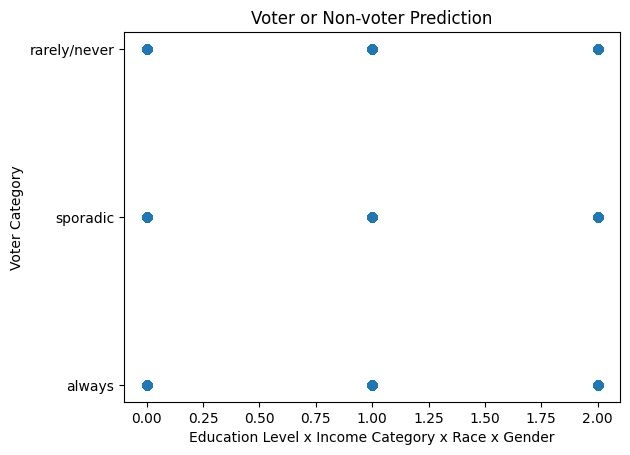

In [ ]:
plt.title('Voter or Non-voter Prediction')
plt.xlabel('Education Level x Income Category x Race x Gender')
plt.ylabel('Voter Category')
plt.scatter(df['educ'], df['voter_category'])
plt.show()